In [1]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import seaborn as sns
from polars import selectors as cs
from module.myload import load_data

warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
train,_ = load_data()
train = pl.DataFrame(train)
print(f"train load complete\r\nsize {train.shape}")

train load complete
size (1458, 80)


<Axes: >

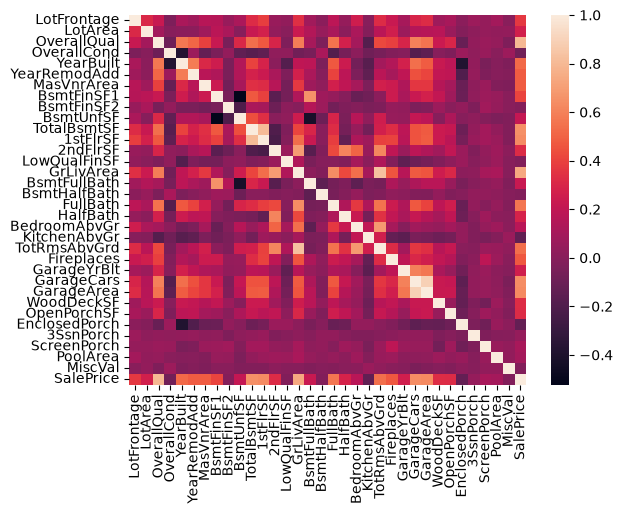

In [3]:
corr = train.select(cs.numeric()).to_pandas().corr()  # type:ignore
sns.heatmap(corr,xticklabels=True, yticklabels=True)

In [4]:
corr["SalePrice"].sort_values(ascending=False).head(10)

SalePrice       1.000000
OverallQual     0.795774
GrLivArea       0.734968
TotalBsmtSF     0.651153
GarageCars      0.641047
1stFlrSF        0.631530
GarageArea      0.629217
FullBath        0.562165
TotRmsAbvGrd    0.537769
YearBuilt       0.523608
Name: SalePrice, dtype: float64

<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

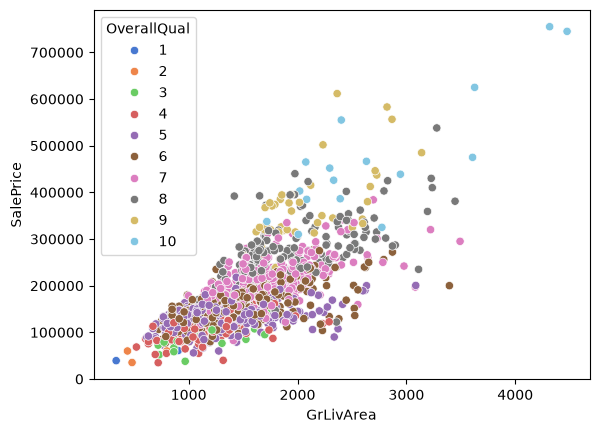

In [5]:
sns.scatterplot(
    data=train,
    x="GrLivArea",
    y="SalePrice",
    hue="OverallQual",
    palette='muted')

----- skewness -----
OverallQual    0.200786
GrLivArea      1.010992
TotalBsmtSF    0.511703
dtype: float64
----- kurtosis -----
OverallQual    0.074960
GrLivArea      2.063463
TotalBsmtSF    1.770105
dtype: float64


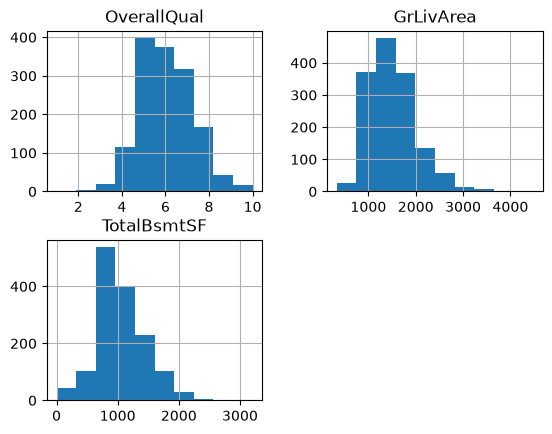

In [6]:
# SalePriceとの相関係数トップ3の分布をチェック
high_corr_cols = corr["SalePrice"].sort_values(ascending=False)[1:4].index.to_list()
high_corr = train.select(high_corr_cols).to_pandas()  # type:ignore

def show_stats(df:pd.DataFrame)->None:
    print("----- skewness -----") 
    print(df.skew()) 
    print("----- kurtosis -----") 
    print(df.kurt())
    df.hist()
    
show_stats(high_corr)

----- skewness -----
OverallQual    0.200786
GrLivArea      0.000557
TotalBsmtSF    0.511703
dtype: float64
----- kurtosis -----
OverallQual    0.074960
GrLivArea      0.074292
TotalBsmtSF    1.770105
dtype: float64


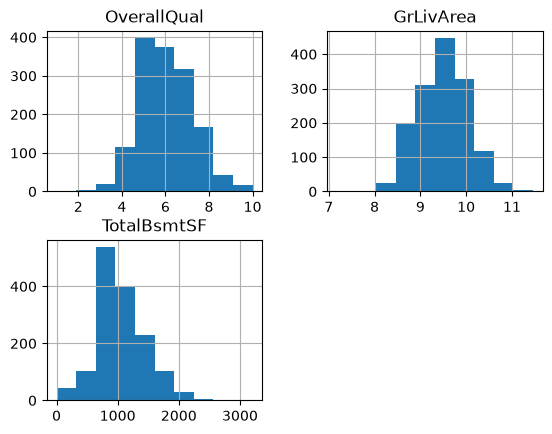

In [7]:
# BoxCox変換
from scipy.stats import boxcox

skew_th = 0.7

bc_transformed_top3 = high_corr.copy()

for col in bc_transformed_top3.columns:
    skew = bc_transformed_top3[col].skew()
    if skew >= skew_th:
        if bc_transformed_top3[col].min() == 0:
            bc_transformed_top3[col] += 1
        bc_transformed_top3[col],_ = boxcox(bc_transformed_top3[col])

show_stats(bc_transformed_top3)
# bc_transformed_top3.describe()

In [8]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# SalePriceとの相関係数トップ3でクラスタリング
# kmeans_inputs = train.select([
#     "OverallQual",
#     "GrLivArea",
#     "GarageArea",
#     # "SalePrice"
#     ])

kmeans_inputs = train.select(cs.numeric())
scaler = StandardScaler()

# クラスタリング実行
cluster_size = 5
standardized_mat = scaler.fit_transform(kmeans_inputs.to_pandas())
kmeans = KMeans(n_clusters=cluster_size,random_state=42)
clustering_df = kmeans_inputs.with_columns(cluster = kmeans.fit_predict(standardized_mat))

clustering_df.head(3)

LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,SalePrice,cluster
f64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64,f64,f64,i64,i64,i64,i64,i64,i64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,f64,i32
65.0,8450,7,5,2003,2003.0,196.0,706.0,0.0,150.0,856.0,856,854,0,1710,1.0,0.0,2,1,3,1,8,0,2003.0,2.0,548.0,0,61,0,0,0,0,0,208500.0,2
80.0,9600,6,8,1976,1976.0,0.0,978.0,0.0,284.0,1262.0,1262,0,0,1262,0.0,1.0,2,0,3,1,6,1,1976.0,2.0,460.0,298,0,0,0,0,0,0,181500.0,1
68.0,11250,7,5,2001,2002.0,162.0,486.0,0.0,434.0,920.0,920,866,0,1786,1.0,0.0,2,1,3,1,6,1,2001.0,2.0,608.0,0,42,0,0,0,0,0,223500.0,2


cluster,count,mean,median,min,max,width,rank
i32,u32,f64,f64,f64,f64,f64,i8
3,199,320656.422111,305900.0,147000.0,755000.0,608000.0,1
1,274,192010.981752,180000.0,82500.0,392500.0,310000.0,2
2,430,187332.644186,184000.0,87000.0,315000.0,228000.0,3
0,474,123326.628692,127000.0,35311.0,188700.0,153389.0,4
4,81,103317.283951,100000.0,34900.0,200500.0,165600.0,5


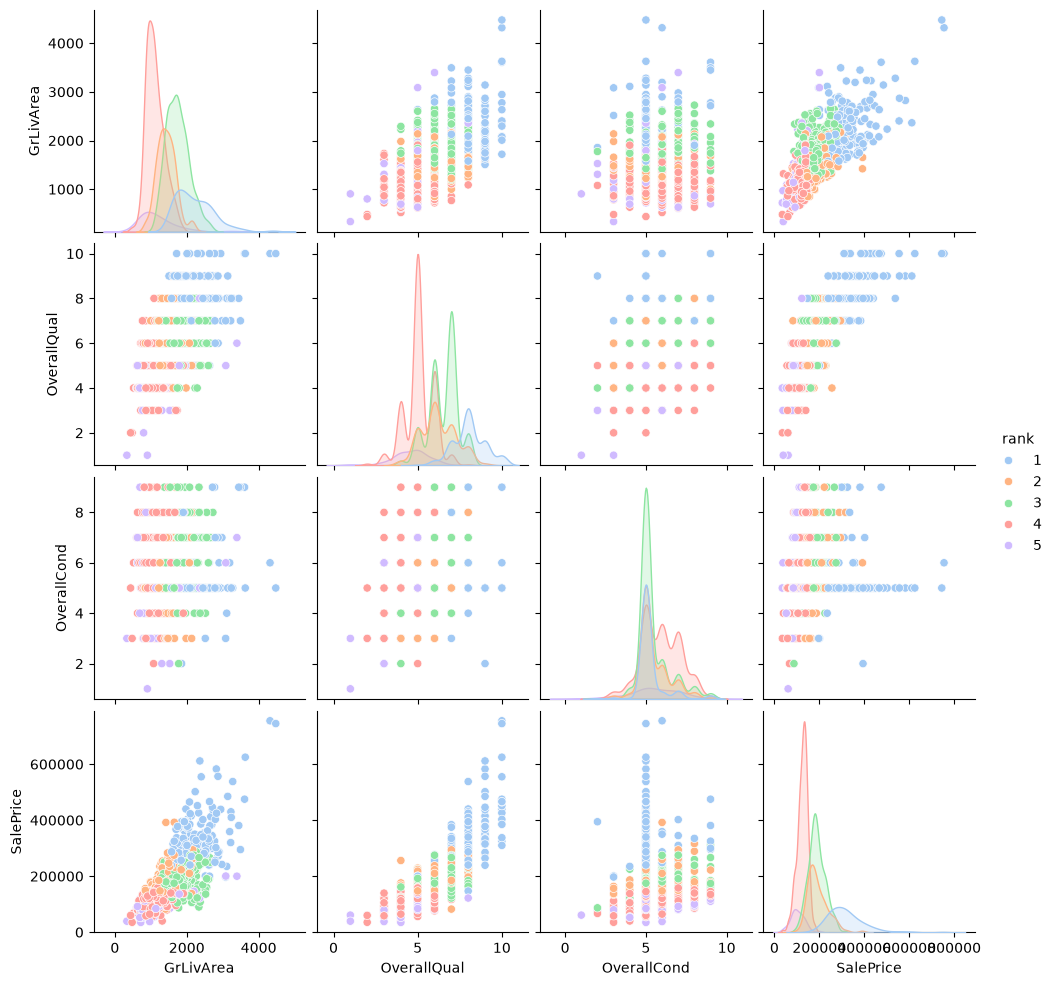

In [10]:
# クラスタリング結果のサマリdfを作成
clustering_df_agg = train \
    .with_columns(clustering_df['cluster']) \
    .group_by("cluster") \
    .agg(
        pl.len().alias("count"),
        pl.col("SalePrice").mean().alias("mean"),
        pl.col("SalePrice").median().alias("median"),
        pl.col("SalePrice").min().alias("min"),
        pl.col("SalePrice").max().alias("max"),
    ).with_columns(
        width = pl.col("max") - pl.col("min"),
        rank = pl.col("mean").rank(descending=True).cast(pl.Int8)
    )
    
# クラスタ毎のSalePriceランク列を付与
clustering_df = clustering_df.join(
    clustering_df_agg.select(["cluster","rank"]),
    "cluster",
    "left")

# 結果確認
pl.Config.set_tbl_rows(-1)
display(clustering_df_agg.sort("rank"))
pl.Config.restore_defaults()
sns.pairplot(
    data=clustering_df.with_columns(SalePrice=train["SalePrice"]).select(["GrLivArea","OverallQual","OverallCond","SalePrice","rank"]).to_pandas(),
    hue="rank",palette="pastel")